In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manoj223/ppe-kit-dataset")

print("Path to dataset files:", path)

Mounting files to /kaggle/input/datasets/manoj223/ppe-kit-dataset...
Path to dataset files: /kaggle/input/datasets/manoj223/ppe-kit-dataset


In [2]:
import os
import shutil
import random
import time
import yaml
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

import sys
sys.path.append("/kaggle/input/models/nutsharshvardhan/v11/pytorch/default/1")

from tqdm import tqdm
from collections import Counter, defaultdict

import torch
from ultralytics import YOLO

from PIL import Image
from IPython.display import display

print("Ultralytics Ready")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics Ready


In [6]:
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memory:", round(torch.cuda.get_device_properties(0).total_memory/1e9,2), "GB")

CUDA Available: True
GPU: Tesla T4
Memory: 15.64 GB


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:0000:01


In [7]:
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memory:", round(torch.cuda.get_device_properties(0).total_memory/1e9,2), "GB")

CUDA Available: True
GPU: Tesla T4
Memory: 15.64 GB


In [9]:
import os

# Biến path là đường dẫn bạn nhận được từ kagglehub
# path = kagglehub.dataset_download("manoj223/ppe-kit-dataset")

print(f"Đang kiểm tra thư mục: {path}\n")

# Duyệt qua các thư mục và in ra cấu trúc (giới hạn in 5 file đầu tiên để không bị trôi terminal)
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]: 
        print(f"{subindent}📄 {f}")
    if len(files) > 5:
        print(f"{subindent}... và {len(files) - 5} file khác")

Đang kiểm tra thư mục: /kaggle/input/datasets/manoj223/ppe-kit-dataset

📁 ppe-kit-dataset/
    📁 TOTALLY_MERGED_DATASET_FOR_TRAINING_6/
        📁 TOTALLY_MERGED_DATASET_FOR_TRAINING_6/
            📄 data.yaml
            📁 val/
                📁 labels/
                    📄 Shounak_TATA_image_2336.txt
                    📄 Ananya_Aparava_1_Frames_01061.txt
                    📄 Apraava_Ananya_548.txt
                    📄 Full_PPE_Dataset_Image_286.txt
                    📄 Manoj_No_Safetyvast2_annotation_153.txt
                    ... và 4626 file khác
                📁 images/
                    📄 Ananya_Aparava_1_Frames_01230.jpg
                    📄 Apraava_Avijit_618.jpg
                    📄 Ananya_Tkil0446.jpg
                    📄 Apraava_Ananya_584.jpg
                    📄 Manoj_Apraava_annotation_648.jpg
                    ... và 4777 file khác
            📁 test/
                📁 labels/
                    📄 Koushik_TKIL_001180.txt
                    📄 Ananya_Aparav

In [10]:
import yaml
import os

# (Giả sử biến 'path' vẫn đang lưu đường dẫn từ cell 1)
# Nếu chạy cell mới bị lỗi chưa define 'path', bạn copy lại dòng: 
# path = kagglehub.dataset_download("manoj223/ppe-kit-dataset")

# Trỏ chính xác vào file data.yaml dựa trên cấu trúc bạn vừa in ra
yaml_file = os.path.join(path, "TOTALLY_MERGED_DATASET_FOR_TRAINING_6", "TOTALLY_MERGED_DATASET_FOR_TRAINING_6", "data.yaml")

if os.path.exists(yaml_file):
    with open(yaml_file, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)
        
        print("=== THÔNG TIN CLASSES BẢO HỘ LAO ĐỘNG (PPE) ===")
        print(f"Tổng số classes (nc): {data.get('nc')}")
        print("-" * 30)
        
        names = data.get('names')
        # Tùy thuộc cấu trúc file yaml, names có thể là list hoặc dict
        if isinstance(names, list): 
            for i, name in enumerate(names):
                print(f"  Class ID {i}: {name}")
        elif isinstance(names, dict): 
            for key, value in names.items():
                print(f"  Class ID {key}: {value}")
else:
    print(f"Không tìm thấy file tại: {yaml_file}")

=== THÔNG TIN CLASSES BẢO HỘ LAO ĐỘNG (PPE) ===
Tổng số classes (nc): 9
------------------------------
  Class ID 0: Helmet
  Class ID 1: Safety_Vest
  Class ID 2: Safety_goggles
  Class ID 3: Safety_shoes
  Class ID 4: NO_helmet
  Class ID 5: NO_Vest
  Class ID 6: NO_goggles
  Class ID 7: No_SafetyShoes
  Class ID 8: Person
  Class ID 9: Slippers


In [ ]:
import os
import glob
from collections import Counter, defaultdict
import pandas as pd
ROOT = os.path.join(path, "TOTALLY_MERGED_DATASET_FOR_TRAINING_6", "TOTALLY_MERGED_DATASET_FOR_TRAINING_6")

label_files = glob.glob(os.path.join(ROOT, "*", "labels", "*.txt"))

print("Tổng số file nhãn (labels) tìm thấy:", len(label_files))

CLASS_NAMES = [
    "Helmet",          # 0
    "Safety_Vest",     # 1
    "Safety_goggles",  # 2
    "Safety_shoes",    # 3
    "NO_helmet",       # 4
    "NO_Vest",         # 5
    "NO_goggles",      # 6
    "No_SafetyShoes",  # 7
    "Person",          # 8
    "Slippers"         # 9
]


box_counts = Counter()              # Đếm tổng số bounding boxes
image_counts = Counter()            # Đếm số lượng ảnh chứa class đó
multi_counter = defaultdict(set)    # Lưu set các ảnh chứa class (không dùng tới trong code hiển thị nhưng giữ lại theo code gốc của bạn)


for file in label_files:
    file_name = os.path.basename(file)
    present_classes = set()
    
    with open(file, "r", encoding='utf-8') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        
        if len(parts) < 5:
            continue
        cls = int(float(parts[0])) 
        
        if cls < len(CLASS_NAMES):
            box_counts[cls] += 1
            present_classes.add(cls)
    
    for cls in present_classes:
        image_counts[cls] += 1

rows = []

for i, name in enumerate(CLASS_NAMES):
    rows.append({
        "Class_ID": i,
        "Class_Name": name,
        "Total_Boxes": box_counts[i],
        "Images_With_Class": image_counts[i]
    })

df = pd.DataFrame(rows)

df = df.sort_values("Total_Boxes").reset_index(drop=True)

print("\nBẢNG THỐNG KÊ DATASET:\n")
print(df.to_string())

Tổng số file nhãn (labels) tìm thấy: 23246

BẢNG THỐNG KÊ DATASET:

   Class_ID      Class_Name  Total_Boxes  Images_With_Class
0         2  Safety_goggles          227                183
1         9        Slippers         1463                884
2         6      NO_goggles         3274               2490
3         7  No_SafetyShoes         5973               2504
4         1     Safety_Vest        10356               7386
5         4       NO_helmet        11827               6168
6         3    Safety_shoes        47279              14441
7         5         NO_Vest        51751              13089
8         8          Person        58434              13735
9         0          Helmet        68396              18080


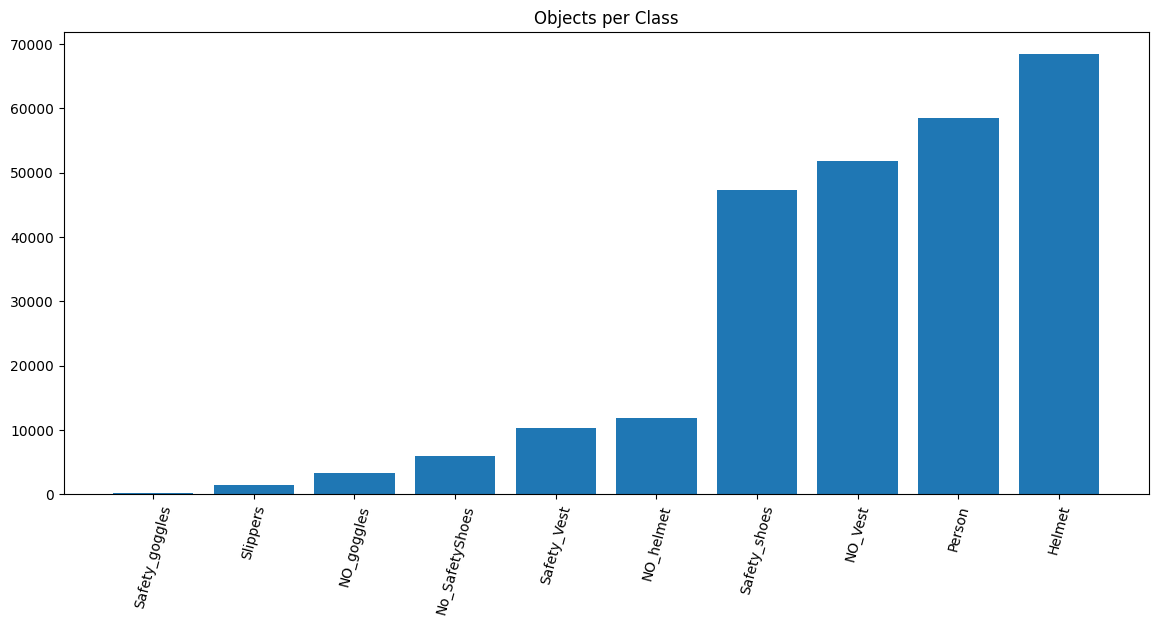

In [12]:
plt.figure(figsize=(14,6))
plt.bar(df["Class_Name"], df["Total_Boxes"])
plt.xticks(rotation=75)
plt.title("Objects per Class")
plt.show()

In [13]:
CLASS_NAMES = [
    "Helmet",          # 0
    "Safety_Vest",     # 1
    "Safety_goggles",  # 2
    "Safety_shoes",    # 3
    "NO_helmet",       # 4
    "NO_Vest",         # 5
    "NO_goggles",      # 6
    "No_SafetyShoes",  # 7
    "Person",          # 8
    "Slippers"         # 9
]

NUM_CLASSES = len(CLASS_NAMES)

for i, val in enumerate(CLASS_NAMES):
    print(f"{i}: {val}")

0: Helmet
1: Safety_Vest
2: Safety_goggles
3: Safety_shoes
4: NO_helmet
5: NO_Vest
6: NO_goggles
7: No_SafetyShoes
8: Person
9: Slippers


In [15]:
import os
import glob
from tqdm import tqdm

# ===============================
# 1. ĐỊNH NGHĨA MAPPING CLASSES (TÙY CHỈNH THEO Ý BẠN)
# ===============================
# Ví dụ dưới đây: Chỉ giữ lại 4 class đồ bảo hộ chuẩn, bỏ qua các class "NO_..." và Person, Slippers
# Cấu trúc: {ID_CŨ: ID_MỚI}
OLD_TO_NEW = {
    0: 0,  # Helmet -> Giữ nguyên ID 0
    1: 1,  # Safety_Vest -> Giữ nguyên ID 1
    2: 2,  # Safety_goggles -> Giữ nguyên ID 2
    3: 3,  # Safety_shoes -> Giữ nguyên ID 3
    # Các ID 4, 5, 6, 7, 8, 9 không có trong dict này sẽ bị XÓA KHỎI FILE LABEL
}

# ===============================
# 2. CÀI ĐẶT ĐƯỜNG DẪN
# ===============================
# Đường dẫn gốc của dataset mới tải
ROOT_DIR = os.path.join(path, "TOTALLY_MERGED_DATASET_FOR_TRAINING_6", "TOTALLY_MERGED_DATASET_FOR_TRAINING_6")
# Đường dẫn lưu dataset đã convert
NEW_ROOT_DIR = "/kaggle/working/converted_dataset"

splits = ['train', 'val', 'test']

# ===============================
# 3. XỬ LÝ CONVERT
# ===============================
for split in splits:
    lbl_dir = os.path.join(ROOT_DIR, split, "labels")
    new_lbl_dir = os.path.join(NEW_ROOT_DIR, split, "labels")
    
    # Tạo thư mục mới nếu chưa có
    os.makedirs(new_lbl_dir, exist_ok=True)
    
    # Quét tất cả file txt trong tập hiện tại
    files = glob.glob(os.path.join(lbl_dir, "*.txt"))
    
    if not files:
        print(f"Không tìm thấy file label nào trong {lbl_dir}")
        continue
        
    print(f"Đang xử lý tập {split.upper()} ({len(files)} files)...")
    
    for file in tqdm(files):
        out_lines = []
        
        with open(file, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
                
            old_cls = int(float(parts[0]))
            
            # Chỉ giữ lại và cập nhật ID nếu class cũ nằm trong dict OLD_TO_NEW
            if old_cls in OLD_TO_NEW:
                parts[0] = str(OLD_TO_NEW[old_cls])
                out_lines.append(" ".join(parts))
        
        # Chỉ tạo file mới nếu file có chứa class hợp lệ (tránh rác)
        if len(out_lines) > 0:
            with open(os.path.join(new_lbl_dir, os.path.basename(file)), 'w', encoding='utf-8') as f:
                f.write("\n".join(out_lines))

print(f"\n✅ Đã convert xong! Labels mới được lưu tại: {NEW_ROOT_DIR}")

Đang xử lý tập TRAIN (16288 files)...


100%|██████████| 16288/16288 [00:13<00:00, 1171.02it/s]


Đang xử lý tập VAL (4631 files)...


100%|██████████| 4631/4631 [00:03<00:00, 1296.21it/s]


Đang xử lý tập TEST (2327 files)...


100%|██████████| 2327/2327 [00:01<00:00, 1423.34it/s]


✅ Đã convert xong! Labels mới được lưu tại: /kaggle/working/converted_dataset


In [25]:
import os
import glob
import yaml

print("🔍 Đang tìm đường dẫn thật của file data.yaml...")

# Quét toàn bộ thư mục input để tìm file data.yaml
yaml_files = glob.glob("/kaggle/input/**/data.yaml", recursive=True)

# Lọc ra đúng file nằm trong thư mục TRAINING_6
target_yaml = None
for f in yaml_files:
    if "TOTALLY_MERGED_DATASET_FOR_TRAINING_6" in f:
        target_yaml = f
        break

if target_yaml is None:
    print("❌ Lỗi: Không tìm thấy! Bạn hãy nhìn cột DATASETS bên phải, click vào dấu 3 chấm cạnh data.yaml và chọn 'Copy file path' để kiểm tra lại nhé.")
else:
    print(f"✅ Đã tìm thấy tại: {target_yaml}")
    
    # Lấy đường dẫn thư mục gốc chứa file yaml vừa tìm được
    dataset_root = os.path.dirname(target_yaml) 
    
    # Đọc file yaml gốc
    with open(target_yaml, 'r', encoding='utf-8') as f:
        data_yaml = yaml.safe_load(f)

    # Gắn lại đường dẫn tuyệt đối cho train/val/test
    data_yaml['train'] = os.path.join(dataset_root, "train", "images")
    data_yaml['val'] = os.path.join(dataset_root, "val", "images")
    
    # Nếu bộ dữ liệu có tập test thì thêm vào, không thì bỏ qua
    if os.path.exists(os.path.join(dataset_root, "test", "images")):
        data_yaml['test'] = os.path.join(dataset_root, "test", "images") 

    # Lưu bản đã sửa ra thư mục /kaggle/working/
    new_yaml_path = "/kaggle/working/data_fixed.yaml"
    with open(new_yaml_path, 'w', encoding='utf-8') as f:
        yaml.dump(data_yaml, f)

    print(f"✅ Đã fix xong đường dẫn! File cấu hình chuẩn được lưu tại: {new_yaml_path}")
    print("👉 GIỜ BẠN CÓ THỂ CHẠY HÀM TRAIN! Nhớ đổi biến data='/kaggle/working/data_fixed.yaml' nhé.")

🔍 Đang tìm đường dẫn thật của file data.yaml...
✅ Đã tìm thấy tại: /kaggle/input/datasets/manoj223/ppe-kit-dataset/TOTALLY_MERGED_DATASET_FOR_TRAINING_6/TOTALLY_MERGED_DATASET_FOR_TRAINING_6/data.yaml
✅ Đã fix xong đường dẫn! File cấu hình chuẩn được lưu tại: /kaggle/working/data_fixed.yaml
👉 GIỜ BẠN CÓ THỂ CHẠY HÀM TRAIN! Nhớ đổi biến data='/kaggle/working/data_fixed.yaml' nhé.


In [ ]:
import time
from ultralytics import YOLO

def train_model(weights, name):
    print(f"🚀 Bắt đầu huấn luyện mô hình với weights: {weights}...")
    start = time.time()
    
    # Khởi tạo mô hình
    model = YOLO(weights)
    
    # Bắt đầu train
    model.train(
        data="/kaggle/working/data_fixed.yaml",  # Đã trỏ vào file YAML bản chuẩn
        epochs=100,
        imgsz=640,
        batch=16,
        workers=4,
        amp=True,
        cache=True,
        patience=10,
        device=0,  # Bắt buộc phải bật GPU trên Kaggle
        optimizer="AdamW",
        lr0=0.001,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,
        project="/kaggle/working/runs",
        name=name,
        pretrained=True,
        exist_ok=True
    )
    
    total = time.time() - start
    print(f"✅ Hoàn thành training trong: {total / 3600:.2f} giờ")
    return total  


train_model(weights="yolov8s.pt", name="ppe_detection_v1")

🚀 Bắt đầu huấn luyện mô hình với weights: yolov8s.pt...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detection_v1, nbs=64, nms=False, opset=None

29975.407742977142

In [31]:
import shutil
import os

# Đường dẫn đến thư mục kết quả của bạn
folder_path = '/kaggle/working/runs'
# Tên file zip bạn muốn tạo
zip_file_name = 'ppe_detection_results'

# Thực hiện nén
shutil.make_archive(zip_file_name, 'zip', folder_path)

print(f"✅ Đã nén xong! File của bạn là: {zip_file_name}.zip")
print(f"Kích thước file: {os.path.getsize(zip_file_name + '.zip') / (1024*1024):.2f} MB")

✅ Đã nén xong! File của bạn là: ppe_detection_results.zip
Kích thước file: 47.88 MB


In [32]:
import shutil
import os
from IPython.display import FileLink, display, Javascript

# 1. Khai báo đường dẫn
folder_path = '/kaggle/working/runs'
zip_file_name = 'ppe_detection_results'
zip_full_name = zip_file_name + '.zip'

# 2. Thực hiện nén thư mục
# Nếu file zip đã tồn tại thì xóa đi để nén mới
if os.path.exists(zip_full_name):
    os.remove(zip_full_name)

shutil.make_archive(zip_file_name, 'zip', folder_path)

print(f"✅ Đã nén xong: {zip_full_name}")
print(f"Kích thước file: {os.path.getsize(zip_full_name) / (1024*1024):.2f} MB")

# 3. Tự động kích hoạt lệnh tải về của trình duyệt
# Lưu ý: Trình duyệt có thể hỏi quyền "Download multiple files", hãy chọn "Allow"
js_code = f"""
var link = document.createElement('a');
link.href = './{zip_full_name}';
link.download = '{zip_full_name}';
document.body.appendChild(link);
link.click();
document.body.removeChild(link);
"""
display(Javascript(js_code))

# 4. Hiển thị thêm link dự phòng nếu trình duyệt chặn tự động tải
print("Nếu file không tự tải về, vui lòng nhấn vào link dưới đây:")
display(FileLink(zip_full_name))

✅ Đã nén xong: ppe_detection_results.zip
Kích thước file: 47.88 MB


<IPython.core.display.Javascript object>

Nếu file không tự tải về, vui lòng nhấn vào link dưới đây:


/kaggle/working/ppe_detection_results.zip

In [28]:
import yaml

# Mở file data_fixed đã tạo ở bước trước
yaml_path = "/kaggle/working/data_fixed.yaml"

with open(yaml_path, 'r', encoding='utf-8') as f:
    data_yaml = yaml.safe_load(f)

# Lấy số lượng class thực tế
actual_nc = len(data_yaml['names'])
print(f"Giá trị nc cũ bị tác giả ghi sai: {data_yaml.get('nc')}")
print(f"Số lượng class thực tế (đúng): {actual_nc}")

# Cập nhật lại cho chuẩn
data_yaml['nc'] = actual_nc

# Lưu đè lại file
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_yaml, f)

print("✅ Đã vá xong lỗi của tác giả! Giờ bạn quay lên chạy lại cell huấn luyện (train_model) là model sẽ chạy mượt mà!")

Giá trị nc cũ bị tác giả ghi sai: 9
Số lượng class thực tế (đúng): 10
✅ Đã vá xong lỗi của tác giả! Giờ bạn quay lên chạy lại cell huấn luyện (train_model) là model sẽ chạy mượt mà!
